# MiniGrid RSSM World Model + VLM Scorer MPC


In [24]:
# Install dependencies
# !pip uninstall -y torch torchvision torchaudio
# !pip install -q --index-url https://download.pytorch.org/whl/cu121 torch torchvision torchaudio
# !pip install -q gymnasium minigrid pillow imageio matplotlib pandas tqdm transformers safetensors

In [25]:
# ARGS
ENV_ID = "MiniGrid-Empty-Random-6x6-v0"
TEXT_GOAL = "agent at the green goal"

SEED = 7
TRAIN_EPISODES = 120
EVAL_EPISODES = 30
EVAL_SEEDS = list(range(100, 130))

HORIZON = 8
NUM_CANDIDATES = 32
MAX_STEPS = 50

BATCH_SIZE = 64
TRAIN_EPOCHS = 20
LR = 3e-4

ARTIFACT_DIR = "artifacts"

In [26]:
# Imports
import os
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import minigrid
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

os.makedirs(ARTIFACT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device: cuda


In [27]:
# MiniGrid
ACTION_NAMES = {0: "left", 1: "right", 2: "forward"}
N_ACTIONS = 3
STATE_DIM = 5

def find_goal(env):
    grid = env.unwrapped.grid
    for x in range(grid.width):
        for y in range(grid.height):
            obj = grid.get(x, y)
            if obj is not None and obj.type == "goal":
                return (x, y)
    raise RuntimeError("Goal not found")

def extract_state(env):
    ax, ay = env.unwrapped.agent_pos
    gx, gy = find_goal(env)
    return np.array([ax, ay, env.unwrapped.agent_dir, gx, gy], dtype=np.float32)

def oracle_action_from_state(state):
    ax, ay, direction, gx, gy = [int(round(v)) for v in state]
    dx, dy = gx - ax, gy - ay
    if dx > 0:
        desired = 0
    elif dx < 0:
        desired = 2
    elif dy > 0:
        desired = 1
    elif dy < 0:
        desired = 3
    else:
        return 2
    if direction == desired:
        return 2
    turn_right = (desired - direction) % 4
    return 1 if turn_right == 1 else 0

def normalized_state(raw_state, size=6):
    s = np.array(raw_state, dtype=np.float32).copy()
    s[[0, 1, 3, 4]] = s[[0, 1, 3, 4]] / max(size - 1, 1)
    s[2] = s[2] / 3.0
    return s

def denormalize_state(norm_state, size=6):
    s = np.array(norm_state, dtype=np.float32).copy()
    s[[0, 1, 3, 4]] = np.round(np.clip(s[[0, 1, 3, 4]], 0, 1) * (size - 1))
    s[2] = np.round(np.clip(s[2], 0, 1) * 3)
    return s.astype(np.int64)

def goal_distance(raw_state):
    ax, ay, _, gx, gy = raw_state
    return abs(float(gx - ax)) + abs(float(gy - ay))

def success_from_state(raw_state):
    return goal_distance(raw_state) < 0.5

def render_symbolic_state(raw_state, size=6, tile=32):
    state = denormalize_state(normalized_state(raw_state, size), size)
    ax, ay, direction, gx, gy = state
    h = w = size * tile
    img = np.ones((h, w, 3), dtype=np.uint8) * 245

    # Walls.
    img[:tile, :, :] = 70
    img[-tile:, :, :] = 70
    img[:, :tile, :] = 70
    img[:, -tile:, :] = 70

    # Grid lines.
    for i in range(size + 1):
        img[i * tile : min(i * tile + 2, h), :, :] = 210
        img[:, i * tile : min(i * tile + 2, w), :] = 210

    # Goal.
    gy0, gy1 = gy * tile + 5, (gy + 1) * tile - 5
    gx0, gx1 = gx * tile + 5, (gx + 1) * tile - 5
    img[gy0:gy1, gx0:gx1, :] = np.array([30, 190, 70], dtype=np.uint8)

    # Agent body.
    cy = ay * tile + tile // 2
    cx = ax * tile + tile // 2
    rr = tile // 3
    yy, xx = np.ogrid[:h, :w]
    mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= rr ** 2
    img[mask] = np.array([230, 40, 40], dtype=np.uint8)

    # Direction marker.
    vecs = {0: (1, 0), 1: (0, 1), 2: (-1, 0), 3: (0, -1)}
    vx, vy = vecs[int(direction)]
    ex = int(cx + vx * tile * 0.36)
    ey = int(cy + vy * tile * 0.36)
    img[max(ey-4,0):min(ey+5,h), max(ex-4,0):min(ex+5,w), :] = np.array([255, 255, 255], dtype=np.uint8)
    return img

def make_env(seed=None, render_mode="rgb_array"):
    env = gym.make(ENV_ID, render_mode=render_mode, max_steps=MAX_STEPS)
    obs, info = env.reset(seed=seed)
    return env


In [28]:
# Dataset generation
@dataclass
class TransitionDataset:
    states: torch.Tensor
    actions: torch.Tensor
    next_states: torch.Tensor
    rewards: torch.Tensor
    dones: torch.Tensor

def collect_dataset(num_episodes, seed=0, expert_prob=0.85):
    rows = []
    rng = np.random.default_rng(seed)
    for ep in tqdm(range(num_episodes), desc="collect"):
        env = make_env(seed=seed + ep)
        done = False
        while not done:
            s_raw = extract_state(env)
            if rng.random() < expert_prob:
                a = oracle_action_from_state(s_raw)
            else:
                a = int(rng.integers(0, N_ACTIONS))
            obs, reward, terminated, truncated, info = env.step(a)
            ns_raw = extract_state(env)
            done = terminated or truncated
            shaped = float(reward) + 0.05 * (goal_distance(s_raw) - goal_distance(ns_raw))
            rows.append((s_raw, a, ns_raw, shaped, float(done)))
        env.close()

    states = torch.tensor(np.stack([normalized_state(r[0]) for r in rows]), dtype=torch.float32)
    actions = torch.tensor([r[1] for r in rows], dtype=torch.long)
    next_states = torch.tensor(np.stack([normalized_state(r[2]) for r in rows]), dtype=torch.float32)
    rewards = torch.tensor([r[3] for r in rows], dtype=torch.float32).unsqueeze(-1)
    dones = torch.tensor([r[4] for r in rows], dtype=torch.float32).unsqueeze(-1)
    return TransitionDataset(states, actions, next_states, rewards, dones)

dataset = collect_dataset(TRAIN_EPISODES, seed=SEED)
print("transitions:", len(dataset.states))


collect:   0%|          | 0/120 [00:00<?, ?it/s]

transitions: 656


## Compact RSSM World Model

This model has a deterministic recurrent state `h_t` and a stochastic latent `z_t`, similar in spirit to PlaNet/Dreamer RSSM. It predicts:

- posterior/prior latent distributions,
- next compact state,
- reward,
- terminal probability.

For planning we use the learned transition prior and decoder to imagine future states from candidate action sequences.


In [29]:
# RSSM-style world model
class RSSMWorldModel(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=N_ACTIONS, deter_dim=128, stoch_dim=32, hidden_dim=128):
        super().__init__()
        self.action_dim = action_dim
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim

        self.obs_encoder = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
        )
        self.gru = nn.GRUCell(stoch_dim + action_dim, deter_dim)
        self.prior = nn.Sequential(
            nn.Linear(deter_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * stoch_dim),
        )
        self.posterior = nn.Sequential(
            nn.Linear(deter_dim + hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * stoch_dim),
        )
        self.state_decoder = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, state_dim),
            nn.Sigmoid(),
        )
        self.reward_head = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 1),
        )
        self.done_head = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 1),
        )

    def dist(self, stats):
        mean, log_std = torch.chunk(stats, 2, dim=-1)
        std = F.softplus(log_std) + 1e-4
        return mean, std

    def sample(self, mean, std):
        return mean + torch.randn_like(std) * std

    def observe_step(self, state, action, prev_h=None, prev_z=None):
        batch = state.shape[0]
        if prev_h is None:
            prev_h = torch.zeros(batch, self.deter_dim, device=state.device)
        if prev_z is None:
            prev_z = torch.zeros(batch, self.stoch_dim, device=state.device)
        a_onehot = F.one_hot(action, self.action_dim).float()
        h = self.gru(torch.cat([prev_z, a_onehot], dim=-1), prev_h)
        prior_mean, prior_std = self.dist(self.prior(h))
        emb = self.obs_encoder(state)
        post_mean, post_std = self.dist(self.posterior(torch.cat([h, emb], dim=-1)))
        z = self.sample(post_mean, post_std)
        feat = torch.cat([h, z], dim=-1)
        pred_state = self.state_decoder(feat)
        reward = self.reward_head(feat)
        done_logit = self.done_head(feat)
        return {
            "h": h, "z": z,
            "prior_mean": prior_mean, "prior_std": prior_std,
            "post_mean": post_mean, "post_std": post_std,
            "pred_state": pred_state,
            "reward": reward,
            "done_logit": done_logit,
        }

    @torch.no_grad()
    def init_latent_from_state(self, state):
        batch = state.shape[0]
        h = torch.zeros(batch, self.deter_dim, device=state.device)
        z0 = torch.zeros(batch, self.stoch_dim, device=state.device)
        dummy_action = torch.zeros(batch, dtype=torch.long, device=state.device)
        out = self.observe_step(state, dummy_action, h, z0)
        return out["h"], out["z"]

    def imagine_step(self, h, z, action, deterministic=True):
        a_onehot = F.one_hot(action, self.action_dim).float()
        h = self.gru(torch.cat([z, a_onehot], dim=-1), h)
        mean, std = self.dist(self.prior(h))
        z = mean if deterministic else self.sample(mean, std)
        feat = torch.cat([h, z], dim=-1)
        pred_state = self.state_decoder(feat)
        reward = self.reward_head(feat)
        done_prob = torch.sigmoid(self.done_head(feat))
        return h, z, pred_state, reward, done_prob

def kl_normal(mean_q, std_q, mean_p, std_p):
    var_q = std_q.pow(2)
    var_p = std_p.pow(2)
    return 0.5 * ((var_q + (mean_q - mean_p).pow(2)) / var_p - 1 + 2 * (torch.log(std_p) - torch.log(std_q))).sum(-1).mean()

model = RSSMWorldModel().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)


epoch 1/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 2/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 3/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 4/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 5/20:   0%|          | 0/11 [00:00<?, ?it/s]

...

epoch 16/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 17/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 18/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 19/20:   0%|          | 0/11 [00:00<?, ?it/s]

epoch 20/20:   0%|          | 0/11 [00:00<?, ?it/s]

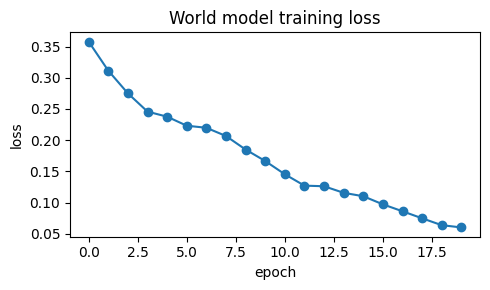

In [30]:
# Train world model
def train_world_model(model, data, epochs):
    n = len(data.states)
    losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        pbar = tqdm(range(0, n, BATCH_SIZE), desc=f"epoch {epoch+1}/{epochs}")
        epoch_losses = []
        for start in pbar:
            idx = perm[start:start + BATCH_SIZE]
            s = data.states[idx].to(device)
            a = data.actions[idx].to(device)
            ns = data.next_states[idx].to(device)
            r = data.rewards[idx].to(device)
            d = data.dones[idx].to(device)

            out = model.observe_step(ns, a)
            state_loss = F.mse_loss(out["pred_state"], ns)
            reward_loss = F.mse_loss(out["reward"], r)
            done_loss = F.binary_cross_entropy_with_logits(out["done_logit"], d)
            kl = kl_normal(out["post_mean"], out["post_std"], out["prior_mean"], out["prior_std"])
            loss = state_loss + reward_loss + 0.2 * done_loss + 1e-3 * kl

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 100.0)
            opt.step()

            epoch_losses.append(float(loss.detach().cpu()))
            pbar.set_postfix(loss=np.mean(epoch_losses[-20:]))
        losses.append(np.mean(epoch_losses))
    return losses

losses = train_world_model(model, dataset, TRAIN_EPOCHS)
torch.save(model.state_dict(), f"{ARTIFACT_DIR}/rssm_world_model.pt")

plt.figure(figsize=(5, 3))
plt.plot(losses, marker="o")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("World model training loss")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/training_loss.png", dpi=160)
plt.show()


## VLM Scorer

The scorer exposes a text-conditioned image scoring API. It first tries to use CLIP from `transformers`. If weights cannot be loaded in the runtime, it falls back to a deterministic MiniGrid frame scorer that analyzes the rendered future frame. The fallback keeps the notebook runnable offline, while preserving the planning interface: future imagined RGB frames are scored against the text goal.


In [31]:
# VLM-style scorer
class CLIPGoalScorer():
    def __init__(self, device):
        self.device = device
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.model.eval()

    @torch.no_grad()
    def score_frames(self, frames, text_goal):
        # Positive prompt versus a deliberately negative prompt.
        images = [Image.fromarray(f.astype(np.uint8)).convert("RGB") for f in frames]
        prompts = [text_goal, "agent far away from the green goal"]
        inputs = self.processor(text=prompts, images=images, return_tensors="pt", padding=True).to(self.device)
        out = self.model(**inputs)
        probs = out.logits_per_image.softmax(dim=-1)[:, 0]
        return probs.detach().cpu().numpy()
        
vlm_scorer = CLIPGoalScorer(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
# MPC planning via imagined rollouts
@torch.no_grad()
def imagine_sequence(model, current_raw_state, action_sequences):
    model.eval()
    num_candidates, horizon = action_sequences.shape
    s0 = torch.tensor(
        np.stack([normalized_state(current_raw_state)] * num_candidates),
        dtype=torch.float32,
        device=device,
    )
    h, z = model.init_latent_from_state(s0)
    pred_states = []
    pred_rewards = []
    done_probs = []
    for t in range(horizon):
        a = torch.tensor(action_sequences[:, t], dtype=torch.long, device=device)
        h, z, ps, pr, dp = model.imagine_step(h, z, a, deterministic=True)
        pred_states.append(ps.detach().cpu().numpy())
        pred_rewards.append(pr.detach().cpu().numpy().squeeze(-1))
        done_probs.append(dp.detach().cpu().numpy().squeeze(-1))
    pred_states = np.stack(pred_states, axis=1)
    pred_rewards = np.stack(pred_rewards, axis=1)
    done_probs = np.stack(done_probs, axis=1)
    return pred_states, pred_rewards, done_probs

def planner_action(model, current_raw_state, mode="wm_vlm", rng=None):
    rng = rng or np.random.default_rng()
    action_sequences = rng.integers(0, N_ACTIONS, size=(NUM_CANDIDATES, HORIZON), dtype=np.int64)
    pred_states, pred_rewards, done_probs = imagine_sequence(model, current_raw_state, action_sequences)

    # Baseline objective: world-model reward + learned terminal probability only.
    objective = pred_rewards.sum(axis=1) + 2.0 * done_probs.max(axis=1)

    if mode == "wm_vlm":
        # Score all future frames. Use max over horizon: reaching the goal at any imagined future step is good.
        frames = []
        for c in range(NUM_CANDIDATES):
            for t in range(HORIZON):
                raw = denormalize_state(pred_states[c, t])
                frames.append(render_symbolic_state(raw))
        scores = vlm_scorer.score_frames(frames, TEXT_GOAL).reshape(NUM_CANDIDATES, HORIZON)
        objective = objective + 0.2 * scores.max(axis=1)
    elif mode == "wm_no_vlm":
        pass
    else:
        raise ValueError(mode)

    best = int(np.argmax(objective))
    return int(action_sequences[best, 0]), {
        "best_objective": float(objective[best]),
        "best_sequence": action_sequences[best].tolist(),
    }

def run_episode(policy_name, seed, record=False):
    env = make_env(seed=seed)
    rng = np.random.default_rng(seed)
    frames = []
    total_reward = 0.0
    success = False

    for step in range(MAX_STEPS):
        raw_state = extract_state(env)
        if record:
            frames.append(env.render())

        if policy_name == "random":
            action = int(rng.integers(0, N_ACTIONS))
        elif policy_name == "wm_no_vlm":
            action, _ = planner_action(model, raw_state, mode="wm_no_vlm", rng=rng)
        elif policy_name == "wm_vlm":
            action, _ = planner_action(model, raw_state, mode="wm_vlm", rng=rng)
        else:
            raise ValueError(policy_name)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        done = terminated or truncated
        if terminated:
            success = True
        if done:
            if record:
                frames.append(env.render())
            break

    env.close()
    return {"policy": policy_name, "seed": seed, "return": total_reward, "success": int(success), "steps": step + 1}, frames


In [39]:
# Eval
policies = ["random", "wm_no_vlm", "wm_vlm"]
records = []
example_frames = {}

for policy in policies:
    for i, seed in enumerate(tqdm(EVAL_SEEDS, desc=policy)):
        rec, frames = run_episode(policy, seed, record=(i == 0))
        records.append(rec)
        if i == 0:
            example_frames[policy] = frames

results = pd.DataFrame(records)
summary = results.groupby("policy").agg(
    episodes=("seed", "count"),
    success_rate=("success", "mean"),
    mean_return=("return", "mean"),
    mean_steps=("steps", "mean"),
).reset_index()

results.to_csv(f"{ARTIFACT_DIR}/episode_results.csv", index=False)
summary.to_csv(f"{ARTIFACT_DIR}/summary.csv", index=False)
display(summary)

random:   0%|          | 0/30 [00:00<?, ?it/s]

wm_no_vlm:   0%|          | 0/30 [00:00<?, ?it/s]

wm_vlm:   0%|          | 0/30 [00:00<?, ?it/s]

,policy,episodes,success_rate,mean_return,mean_steps
0,random,30,0.300000,0.147600,43.466667
1,wm_no_vlm,30,0.700000,0.477400,27.366667
2,wm_vlm,30,0.733333,0.438733,29.700000


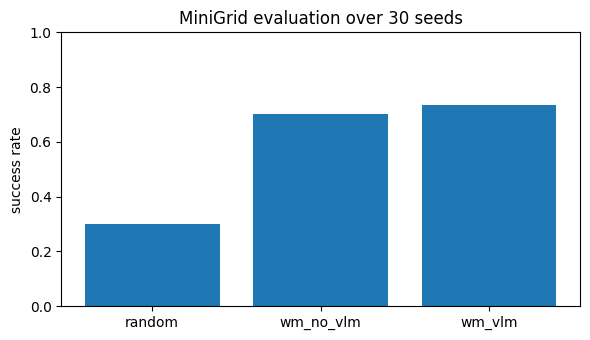

artifacts/random_episode.gif
artifacts/wm_no_vlm_episode.gif
artifacts/wm_vlm_episode.gif


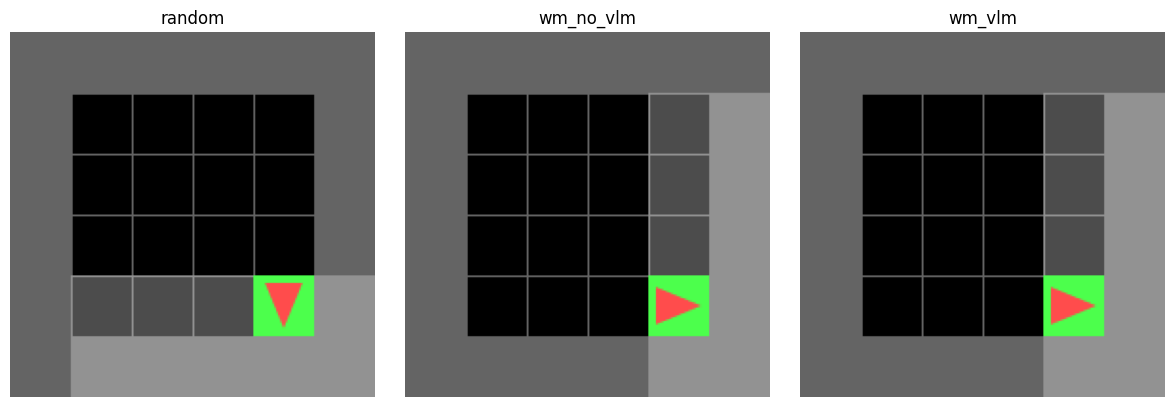

In [40]:
# Viz
plt.figure(figsize=(6, 3.5))
plt.bar(summary["policy"], summary["success_rate"])
plt.ylim(0, 1.0)
plt.ylabel("success rate")
plt.title(f"MiniGrid evaluation over {len(EVAL_SEEDS)} seeds")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/success_rate.png", dpi=180)
plt.show()

for policy, frames in example_frames.items():
    if frames:
        path = f"{ARTIFACT_DIR}/{policy}_episode.gif"
        imageio.mimsave(path, frames, fps=4)
        print(path)

fig, axes = plt.subplots(1, len(policies), figsize=(12, 4))
for ax, policy in zip(axes, policies):
    frames = example_frames.get(policy, [])
    ax.imshow(frames[-1] if frames else np.zeros((64, 64, 3), dtype=np.uint8))
    ax.set_title(policy)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/final_frames.png", dpi=180)
plt.show()
